#### Handson 2
#### Deep Learning 
##### Hamed Ahmadinia

#### 1. GPU check

In [45]:
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch: 2.9.1+cu129
cuda available: True
gpu: Tesla V100-SXM2-32GB
device: cuda


#### 2. Imports + seed

In [46]:
import os
import random
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#### 3. Unzip data.zip into current directory

In [47]:
zip_path = Path("data.zip")

if zip_path.exists():
    print("Found data.zip -> extracting into current directory (.) ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Extracted.")
else:
    print("data.zip not found here. Skipping unzip (maybe already extracted).")

Found data.zip -> extracting into current directory (.) ...
Extracted.


#### 4. Locate the Kaggle Dogs vs Cats flat train folder

In [48]:
def find_flat_kaggle_train_dir() -> Path:
    candidates = [
        Path("dogs-vs-cats/train/train"),
        Path("data/dogs-vs-cats/train/train"),
        Path("data/data/dogs-vs-cats/train/train"),
    ]
    # also search a bit deeper if needed
    for base in [Path("."), Path("data"), Path("data/data")]:
        if base.exists():
            for p in base.rglob("dogs-vs-cats/train/train"):
                candidates.append(p)

    for p in candidates:
        if p.exists() and p.is_dir():
            # check it contains cat.*.jpg / dog.*.jpg
            sample = list(p.glob("*.jpg"))[:5]
            if sample:
                return p.resolve()
    raise RuntimeError("Could not find the flat Kaggle folder train/train with .jpg images.")

flat_dir = find_flat_kaggle_train_dir()
print("Found flat Kaggle train dir:", flat_dir)
print("Sample files:", [f.name for f in list(flat_dir.glob('*.jpg'))[:5]])

Found flat Kaggle train dir: /users/hahmadin/hands on 2/data/dogs-vs-cats/train/train
Sample files: ['cat.4993.jpg', 'cat.2878.jpg', 'dog.4888.jpg', 'dog.8324.jpg', 'cat.8374.jpg']


#### 5. Build ImageFolder-style dataset using symlinks 

In [49]:
out_dir = flat_dir.parent / "train_split"   # next to the flat_dir
cat_dir = out_dir / "cat"
dog_dir = out_dir / "dog"
cat_dir.mkdir(parents=True, exist_ok=True)
dog_dir.mkdir(parents=True, exist_ok=True)

# Create symlinks if not already created
created = 0
skipped = 0

for img in flat_dir.glob("*.jpg"):
    name = img.name.lower()
    if name.startswith("cat."):
        target = cat_dir / img.name
    elif name.startswith("dog."):
        target = dog_dir / img.name
    else:
        continue

    if target.exists():
        skipped += 1
        continue

    target.symlink_to(img.resolve())
    created += 1

print("train_split created at:", out_dir)
print("Symlinks created:", created, "| skipped existing:", skipped)
print("cat images:", len(list(cat_dir.glob("*.jpg"))))
print("dog images:", len(list(dog_dir.glob("*.jpg"))))

train_split created at: /users/hahmadin/hands on 2/data/dogs-vs-cats/train/train_split
Symlinks created: 0 | skipped existing: 25000
cat images: 12500
dog images: 12500


#### 6. Transforms (ImageNet normalization for ResNet18)

In [50]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

#### 7. Load dataset

In [51]:
data_dir = str(out_dir)   # train_split is the ImageFolder root
full_ds = datasets.ImageFolder(root=data_dir, transform=val_tf)

print("Classes:", full_ds.classes)
print("num_classes:", len(full_ds.classes))
print("Total images:", len(full_ds))

Classes: ['cat', 'dog']
num_classes: 2
Total images: 25000


#### 8. Train/val split + loaders

In [52]:
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

# Apply proper transforms
train_ds.dataset.transform = train_tf
val_ds.dataset.transform = val_tf

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print("Train:", len(train_ds), "Val:", len(val_ds))

# quick label sanity check
x, y = next(iter(train_loader))
print("Train batch labels unique:", torch.unique(y))

Train: 20000 Val: 5000
Train batch labels unique: tensor([0, 1])


#### 9. Model: pretrained ResNet18 + frozen backbone + new head

In [53]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

num_classes = len(full_ds.classes)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)
print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


#### 10. Loss + optimizer

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4, weight_decay=1e-2)

#### 11. Accuracy + training loop (history)

In [55]:
def accuracy(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100.0 * correct / total

def train(model, epochs=10):
    history = {"train_acc": [], "val_acc": [], "loss": []}

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_acc = accuracy(train_loader, model)
        val_acc = accuracy(val_loader, model)
        avg_loss = running_loss / len(train_loader)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["loss"].append(avg_loss)

        print(f"Epoch {epoch:02d}/{epochs} | loss={avg_loss:.4f} | train_acc={train_acc:.2f}% | val_acc={val_acc:.2f}%")

    return history

#### 12. Run training

In [56]:
history = train(model, epochs=10)

print("Final Train Accuracy:", accuracy(train_loader, model))
print("Final Validation Accuracy:", accuracy(val_loader, model))

Epoch 01/10 | loss=0.3936 | train_acc=96.27% | val_acc=96.00%
Epoch 02/10 | loss=0.1933 | train_acc=97.12% | val_acc=97.22%
Epoch 03/10 | loss=0.1574 | train_acc=97.33% | val_acc=97.36%
Epoch 04/10 | loss=0.1442 | train_acc=97.47% | val_acc=97.52%
Epoch 05/10 | loss=0.1347 | train_acc=97.63% | val_acc=97.56%
Epoch 06/10 | loss=0.1323 | train_acc=97.75% | val_acc=97.82%
Epoch 07/10 | loss=0.1247 | train_acc=97.78% | val_acc=97.74%
Epoch 08/10 | loss=0.1229 | train_acc=97.67% | val_acc=97.84%
Epoch 09/10 | loss=0.1229 | train_acc=97.65% | val_acc=97.76%
Epoch 10/10 | loss=0.1247 | train_acc=97.80% | val_acc=97.90%
Final Train Accuracy: 97.8
Final Validation Accuracy: 97.9


#### 13. Plot results

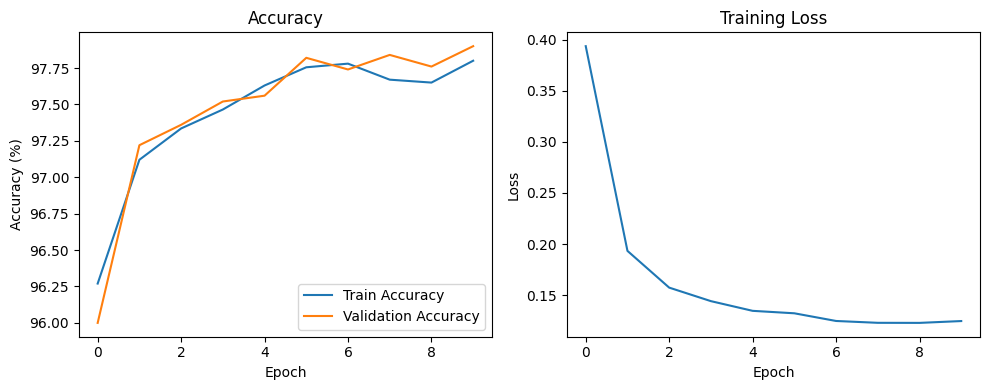

In [57]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.tight_layout()
plt.show()

#### 14. Save model weights

In [58]:
torch.save(model.state_dict(), "resnet18_dogcat_head.pt")
print(" Saved model weights to resnet18_dogcat_head.pt")

 Saved model weights to resnet18_dogcat_head.pt
